# Testing batdetect2 pipeline features:

## **Working on features relevant to the use of this pipeline on recovered Audiomoth .wav recordings**

## 1) Figuring out our imports:

### a) Below are the imports pertaining to accessing data and metadata

In [1]:
from pathlib import Path
import glob
import exiftool
import suncalc
import soundfile as sf
import re

### b) Below are the imports pertaining to data manipulation

In [2]:
import numpy as np
import pandas as pd
import dask.dataframe as dd

### c) Below are the imports pertaining to data visualization

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

### d) Below are the imports pertaining to the use of the MSDS pipeline

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer
import bout.assembly as bt
import bout.clustering as clstr
from cfg import get_config

In [5]:
SEATTLE_LATITUDE = 47.655181
SEATTLE_LONGITUDE = -122.293123
SITE_NAMES = {
            'Central' : "Central Pond",
            'Foliage' : "Foliage",
            'Carp' : "Carp Pond",
            'Telephone' : "Telephone Field",
            'E18' : "E18 Bridge"
                }


Searching for files from recover-20250516 and UBNA_026


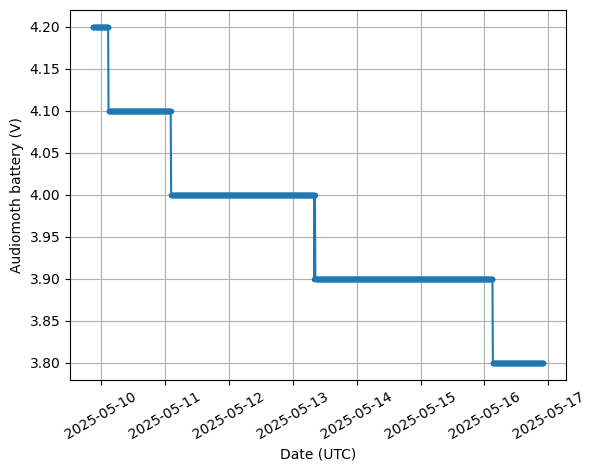

In [6]:
cfg=dict()
cfg["sd_unit"] = '026'
cfg["cycle_length"] = 600
cfg['recording_start'] = '00:00'
cfg['recording_end'] = '23:59'

data_params = dict()
data_params['recover_folder'] = 'recover-20250516'
data_params["audiomoth_folder"] = f"UBNA_{cfg['sd_unit']}"
print(f"Searching for files from {data_params['recover_folder']} and {data_params['audiomoth_folder']}")

cur_data_records = dd.read_csv(f'../output_dir/ubna_data_06_collected_audio_records.csv', dtype=str).compute()
if 'Unnamed: 0' in cur_data_records.columns:
    cur_data_records.drop(columns='Unnamed: 0', inplace=True)
cur_data_records["datetime_UTC"] = pd.DatetimeIndex(cur_data_records["datetime_UTC"])
cur_data_records.set_index("datetime_UTC", inplace=True) 

files_from_deployment_session = batdetect2_pipeline.filter_df_with_deployment_session(cur_data_records, data_params['recover_folder'], cfg)
audiomoth_batteries = []
for battery_val in files_from_deployment_session['audiomoth_battery'].values:
    audiomoth_batteries += [float(battery_val.replace('V',''))]
audiomoth_batteries = np.array(audiomoth_batteries)
files_from_deployment_session['audiomoth_battery'] = audiomoth_batteries
plt.plot(files_from_deployment_session['audiomoth_battery'], marker='.')
plt.ylabel('Audiomoth battery (V)')
plt.xlabel('Date (UTC)')
plt.xticks(rotation=30)
plt.grid(which='both')
plt.show()

In [7]:
from models.bat_call_detector.model_detector import BatCallDetector

In [8]:
detector_args = dict()
detector_args['detection_threshold'] = 0.30
detector_args['chunk_size'] = 2

cfg = dict()
cfg["time_expansion_factor"] = 1.0
# Offset (seconds) from the beginning of the audio file to start processing
cfg["start_time"] = 0.0
# Input audio is divided into segments of this duration (seconds), each processed individually
cfg["segment_duration"] = 30.0
cfg["models"] = [BatCallDetector(detection_threshold=detector_args['detection_threshold'],
                                spec_slices=False,
                                chunk_size=detector_args['chunk_size'],
                                time_expansion_factor=1.0,
                                quiet=False,
                                cnn_features=True)]


cfg["recover_folder"] = 'recover-20251002'
cfg["sd_unit"] = "030"
cfg["site"] = 'Telephone Field'
cfg['recording_start'] = '00:00'
cfg['recording_end'] = '23:59'
cfg['duration'] = 300
cfg['cycle_length'] = 600
cfg["output_dir"] = Path('../output_dir/recover-20251002')
cfg["tmp_dir"] = Path('../output/tmp')
cfg["generate_fig"] = True

In [9]:
# run_pipeline_for_session_with_df(cfg)

data_params = batdetect2_pipeline.get_params_relevant_to_data(cfg)
cfg["csv_filename"] = f"bd2__{data_params['recover_folder']}_{data_params['audiomoth_folder']}"


Searching for files from recover-20251002 and UBNA_030
Will save csv file to ../output_dir/recover-20251002/Telephone Field
All files from deployment session good!


In [10]:
bd_preds = pd.DataFrame()

if not data_params['output_dir'].is_dir():
    data_params['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

packages_to_chunk = []
for path in data_params['good_audio_files']:
    chunk_instructions_and_files = dict()
    chunk_instructions_and_files['audio_file'] = path
    chunk_instructions_and_files['tmp_dir'] = cfg['tmp_dir']
    chunk_instructions_and_files['start_time'] = cfg['start_time']
    chunk_instructions_and_files['segment_duration'] = cfg['segment_duration']
    packages_to_chunk+=[chunk_instructions_and_files]


In [11]:
data_params['resample_in_min'] = 30
data_params['resample_tag'] = f"{data_params['resample_in_min']}min"
data_params['detection_threshold_for_activity'] = 0.35
data_params['SNR_threshold_for_activity'] = 3

In [12]:
csv_tag = cfg["csv_filename"].split('__')[-1]
ref_datetimes = pd.to_datetime(data_params['ref_audio_files'], format="%Y%m%d_%H%M%S", exact=False)
activity_datetimes_for_file = ref_datetimes.tz_localize('UTC')
good_datetimes = pd.to_datetime(data_params['good_audio_files'], format="%Y%m%d_%H%M%S", exact=False)
nodets = 0

rawdets = pd.read_csv(f'{data_params["output_dir"]}/{cfg["csv_filename"]}.csv')
dets = rawdets[(rawdets['det_prob']>=data_params['detection_threshold_for_activity'])&(rawdets['SNR']>=data_params['SNR_threshold_for_activity'])].copy()
dets['ref_time'] = pd.to_datetime(dets['input_file'], format="%Y%m%d_%H%M%S", exact=False)
activity_callrate_arr = pd.DataFrame()
activity_btp_arr = pd.DataFrame()
activity_ai_arr = pd.DataFrame()
dets

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name,ref_time
13,LF,17280.0,6.380714,204.9845,205.0045,16015.0,19137.0,Echolocation,Nyctalus leisleri,0.236,0.356,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:40:00
15,HF,51840.0,16.163696,22.4975,22.5020,45234.0,72030.0,Echolocation,Myotis mystacinus,0.097,0.359,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:50:00
18,LF,22080.0,5.366308,211.6245,211.6297,21171.0,33628.0,Echolocation,Plecotus austriacus,0.301,0.402,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:50:00
19,LF,25920.0,12.354739,277.3655,277.3788,25468.0,29790.0,Echolocation,Nyctalus leisleri,0.420,0.463,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:50:00
20,LF,25920.0,6.646519,50.0245,50.0283,20312.0,51455.0,Echolocation,Myotis nattereri,0.379,0.414,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229399,LF,21120.0,8.818563,186.5195,186.5425,20312.0,23668.0,Echolocation,Nyctalus leisleri,0.386,0.417,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 15:50:00
229403,LF,24960.0,4.350546,214.8195,214.8282,23750.0,31701.0,Echolocation,Nyctalus leisleri,0.120,0.389,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 16:30:00
229404,LF,26880.0,7.903674,62.1485,62.1571,24609.0,31690.0,Echolocation,Eptesicus serotinus,0.120,0.362,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 16:50:00
229407,LF,22080.0,5.410644,183.5815,183.6031,21171.0,24615.0,Echolocation,Nyctalus leisleri,0.357,0.394,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 17:00:00


In [13]:
group = 'LF'
freq_group_df = dets.loc[dets['KMEANS_CLASSES']==group].copy()
freq_group_df

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name,ref_time
13,LF,17280.0,6.380714,204.9845,205.0045,16015.0,19137.0,Echolocation,Nyctalus leisleri,0.236,0.356,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:40:00
18,LF,22080.0,5.366308,211.6245,211.6297,21171.0,33628.0,Echolocation,Plecotus austriacus,0.301,0.402,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:50:00
19,LF,25920.0,12.354739,277.3655,277.3788,25468.0,29790.0,Echolocation,Nyctalus leisleri,0.420,0.463,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:50:00
20,LF,25920.0,6.646519,50.0245,50.0283,20312.0,51455.0,Echolocation,Myotis nattereri,0.379,0.414,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 23:00:00
23,LF,25920.0,8.618048,133.9165,133.9215,19453.0,37713.0,Echolocation,Plecotus austriacus,0.312,0.483,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229399,LF,21120.0,8.818563,186.5195,186.5425,20312.0,23668.0,Echolocation,Nyctalus leisleri,0.386,0.417,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 15:50:00
229403,LF,24960.0,4.350546,214.8195,214.8282,23750.0,31701.0,Echolocation,Nyctalus leisleri,0.120,0.389,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 16:30:00
229404,LF,26880.0,7.903674,62.1485,62.1571,24609.0,31690.0,Echolocation,Eptesicus serotinus,0.120,0.362,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 16:50:00
229407,LF,22080.0,5.410644,183.5815,183.6031,21171.0,24615.0,Echolocation,Nyctalus leisleri,0.357,0.394,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 17:00:00


In [14]:
valid_df = batdetect2_pipeline.prepare_and_threshold_dets_for_activity(freq_group_df, data_params)
valid_df

,start_time_wrt_ref,end_time_wrt_ref,call_start_time,call_end_time,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,...,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name,ref_time,freq_group,cycle_ref_time
13,804.9845,805.0045,2025-09-25 22:43:24.984500000,2025-09-25 22:43:25.004500,LF,17280.0,6.380714,204.9845,205.0045,16015.0,...,0.356,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:43:24.984500000,LF,2025-09-25 22:30:00
18,1411.6245,1411.6297,2025-09-25 22:53:31.624500000,2025-09-25 22:53:31.629700,LF,22080.0,5.366308,211.6245,211.6297,21171.0,...,0.402,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:53:31.624500000,LF,2025-09-25 22:30:00
19,1477.3655,1477.3788,2025-09-25 22:54:37.365500000,2025-09-25 22:54:37.378800,LF,25920.0,12.354739,277.3655,277.3788,25468.0,...,0.463,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 22:54:37.365500000,LF,2025-09-25 22:30:00
20,50.0245,50.0283,2025-09-25 23:00:50.024500000,2025-09-25 23:00:50.028300,LF,25920.0,6.646519,50.0245,50.0283,20312.0,...,0.414,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 23:00:50.024500000,LF,2025-09-25 23:00:00
23,133.9165,133.9215,2025-09-25 23:02:13.916500000,2025-09-25 23:02:13.921500,LF,25920.0,8.618048,133.9165,133.9215,19453.0,...,0.483,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-09-25 23:02:13.916500000,LF,2025-09-25 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229399,1386.5195,1386.5425,2025-10-02 15:53:06.519499999,2025-10-02 15:53:06.542500,LF,21120.0,8.818563,186.5195,186.5425,20312.0,...,0.417,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 15:53:06.519499999,LF,2025-10-02 15:30:00
229403,214.8195,214.8282,2025-10-02 16:33:34.819500000,2025-10-02 16:33:34.828200,LF,24960.0,4.350546,214.8195,214.8282,23750.0,...,0.389,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 16:33:34.819500000,LF,2025-10-02 16:30:00
229404,1262.1485,1262.1571,2025-10-02 16:51:02.148500000,2025-10-02 16:51:02.157100,LF,26880.0,7.903674,62.1485,62.1571,24609.0,...,0.362,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 16:51:02.148500000,LF,2025-10-02 16:30:00
229407,183.5815,183.6031,2025-10-02 17:03:03.581500000,2025-10-02 17:03:03.603100,LF,22080.0,5.410644,183.5815,183.6031,21171.0,...,0.394,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field,2025-10-02 17:03:03.581500000,LF,2025-10-02 17:00:00


In [15]:
all_site_bd2_df = dd.read_csv(f"../output_dir/recover-2025*/{SITE_NAMES[data_params['site_tag']]}/bd2__*.csv").compute()
all_site_bd2_df


,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
0,HF,46080.0,2.891978,70.7505,70.7585,45234.0,50085.0,Echolocation,Pipistrellus pipistrellus,0.203,0.226,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
1,HF,47040.0,3.102002,170.1125,170.1183,46093.0,51169.0,Echolocation,Pipistrellus pipistrellus,0.212,0.220,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
2,LF,22080.0,3.884388,242.0725,242.0764,16875.0,35887.0,Echolocation,Plecotus austriacus,0.165,0.279,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
3,LF,21120.0,3.303940,242.1975,242.2058,18593.0,30909.0,Echolocation,Plecotus austriacus,0.094,0.202,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
4,HF,46080.0,2.651033,296.4745,296.4782,27187.0,50703.0,Echolocation,Myotis daubentonii,0.114,0.229,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45568,LF,21120.0,5.874828,28.6285,28.6534,20312.0,23548.0,Echolocation,Nyctalus leisleri,0.305,0.347,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45569,LF,22080.0,2.219802,77.1035,77.1248,21171.0,25236.0,Echolocation,Nyctalus noctula,0.175,0.316,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45570,LF,24960.0,1.387107,47.4215,47.4337,24609.0,29283.0,Echolocation,Nyctalus leisleri,0.166,0.314,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45571,LF,23040.0,1.537702,272.8695,272.8885,23750.0,27276.0,Echolocation,Nyctalus leisleri,0.216,0.306,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field


In [16]:
# bout_params = batdetect2_pipeline.get_bout_params_from_location(all_site_bd2_df, data_params)
raw_bd2_df = all_site_bd2_df.copy()

raw_bd2_df = raw_bd2_df[(raw_bd2_df['det_prob']>=data_params['detection_threshold_for_activity'])&(raw_bd2_df['SNR']>=data_params['SNR_threshold_for_activity'])]
raw_bd2_df = raw_bd2_df.rename(columns={'KMEANS_CLASSES': 'freq_group'})
file_dts = pd.to_datetime(raw_bd2_df['input_file'], format='%Y%m%d_%H%M%S', exact=False)

anchor_start_times = file_dts + pd.to_timedelta(raw_bd2_df['start_time'].values.astype('float64'), unit='s')
anchor_end_times = file_dts + pd.to_timedelta(raw_bd2_df['end_time'].values.astype('float64'), unit='s') 

raw_bd2_df.insert(0, 'call_end_time', anchor_end_times)
raw_bd2_df.insert(0, 'call_start_time', anchor_start_times)
raw_bd2_df.insert(0, 'ref_time', anchor_start_times)

valid_df = raw_bd2_df[(raw_bd2_df['freq_group']=='LF')|(raw_bd2_df['freq_group']=='HF')]
valid_df = valid_df.sort_values('call_start_time')
valid_df

,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
5,2025-01-13 18:10:06.514499999,2025-01-13 18:10:06.514499999,2025-01-13 18:10:06.529000,LF,26880.0,9.970765,6.5145,6.5290,25468.0,28924.0,Echolocation,Nyctalus leisleri,0.312,0.365,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
32,2025-01-13 18:12:21.894500000,2025-01-13 18:12:21.894500000,2025-01-13 18:12:21.908600,LF,25920.0,8.572555,141.8945,141.9086,25468.0,28642.0,Echolocation,Nyctalus leisleri,0.321,0.353,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
56,2025-01-13 18:21:52.771500000,2025-01-13 18:21:52.771500000,2025-01-13 18:21:52.789400,LF,25920.0,6.194531,112.7715,112.7894,25468.0,28432.0,Echolocation,Nyctalus leisleri,0.296,0.356,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
69,2025-01-13 18:32:45.882500000,2025-01-13 18:32:45.882500000,2025-01-13 18:32:45.904300,LF,25920.0,13.927720,165.8825,165.9043,24609.0,27797.0,Echolocation,Nyctalus leisleri,0.361,0.413,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
90,2025-01-13 18:40:34.560500000,2025-01-13 18:40:34.560500000,2025-01-13 18:40:34.574100,LF,25920.0,11.427359,34.5605,34.5741,25468.0,28596.0,Echolocation,Nyctalus leisleri,0.382,0.430,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45549,2025-10-30 14:44:57.808500000,2025-10-30 14:44:57.808500000,2025-10-30 14:44:57.835600,LF,18240.0,23.770687,297.8085,297.8356,17734.0,20460.0,Echolocation,Nyctalus noctula,0.326,0.392,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45550,2025-10-30 15:00:00.985500000,2025-10-30 15:00:00.985500000,2025-10-30 15:00:01.007600,LF,18240.0,25.603852,0.9855,1.0076,16875.0,21876.0,Echolocation,Nyctalus noctula,0.436,0.508,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45551,2025-10-30 15:00:03.707500000,2025-10-30 15:00:03.707500000,2025-10-30 15:00:03.731400,LF,18240.0,33.081937,3.7075,3.7314,17734.0,20646.0,Echolocation,Nyctalus noctula,0.356,0.428,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45552,2025-10-30 15:00:06.258500000,2025-10-30 15:00:06.258500000,2025-10-30 15:00:06.276700,LF,17280.0,28.019458,6.2585,6.2767,16875.0,21781.0,Echolocation,Nyctalus noctula,0.462,0.596,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field


In [17]:
# bout_params = bt.get_bout_params_from_location(valid_df, data_params)

location_sum_df = valid_df.copy()
bout_params = dict()
bout_params['site_key'] = data_params['site_tag']


In [18]:
location_sum_df['freq_group'].unique()

array(['LF', 'HF'], dtype=object)

In [19]:

group = 'HF'
freq_group_df = location_sum_df.loc[location_sum_df['freq_group']==group].copy()
freq_group_df


,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
131,2025-01-13 18:51:16.455500,2025-01-13 18:51:16.455500,2025-01-13 18:51:16.467400000,HF,48000.0,17.406992,76.4555,76.4674,47812.0,49385.0,Echolocation,Pipistrellus pipistrellus,0.286,0.388,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
968,2025-01-22 01:32:39.659500,2025-01-22 01:32:39.659500,2025-01-22 01:32:39.665600000,HF,52800.0,7.570485,159.6595,159.6656,51250.0,60088.0,Echolocation,Pipistrellus pipistrellus,0.345,0.440,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
971,2025-01-22 01:32:40.086500,2025-01-22 01:32:40.086500,2025-01-22 01:32:40.092100000,HF,50880.0,7.989646,160.0865,160.0921,47812.0,61765.0,Echolocation,Pipistrellus pipistrellus,0.487,0.512,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
972,2025-01-22 01:32:40.176500,2025-01-22 01:32:40.176500,2025-01-22 01:32:40.183400000,HF,51840.0,9.170474,160.1765,160.1834,47812.0,65033.0,Echolocation,Pipistrellus pipistrellus,0.336,0.360,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
973,2025-01-22 01:32:40.261500,2025-01-22 01:32:40.261500,2025-01-22 01:32:40.266500000,HF,51840.0,9.133071,160.2615,160.2665,46093.0,69836.0,Echolocation,Pipistrellus pipistrellus,0.150,0.387,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45539,2025-10-30 10:40:34.860500,2025-10-30 10:40:34.860500,2025-10-30 10:40:34.863400000,HF,48960.0,4.546405,34.8605,34.8634,43515.0,54623.0,Echolocation,Myotis brandtii,0.157,0.402,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45541,2025-10-30 10:40:34.998500,2025-10-30 10:40:34.998500,2025-10-30 10:40:35.002000000,HF,48960.0,19.067724,34.9985,35.0020,40937.0,62859.0,Echolocation,Myotis brandtii,0.419,0.599,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45542,2025-10-30 10:40:35.161500,2025-10-30 10:40:35.161500,2025-10-30 10:40:35.164500000,HF,47040.0,7.780775,35.1615,35.1645,41796.0,58456.0,Echolocation,Myotis brandtii,0.313,0.583,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45543,2025-10-30 10:40:35.234500,2025-10-30 10:40:35.234500,2025-10-30 10:40:35.237400000,HF,46080.0,4.056978,35.2345,35.2374,42656.0,54134.0,Echolocation,Myotis brandtii,0.250,0.445,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field


In [20]:
# ipis_loc, hist_loc = clstr.get_histogram(freq_group_df, 10)
location_sum_df = freq_group_df.copy()
location_sum_df

,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
131,2025-01-13 18:51:16.455500,2025-01-13 18:51:16.455500,2025-01-13 18:51:16.467400000,HF,48000.0,17.406992,76.4555,76.4674,47812.0,49385.0,Echolocation,Pipistrellus pipistrellus,0.286,0.388,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
968,2025-01-22 01:32:39.659500,2025-01-22 01:32:39.659500,2025-01-22 01:32:39.665600000,HF,52800.0,7.570485,159.6595,159.6656,51250.0,60088.0,Echolocation,Pipistrellus pipistrellus,0.345,0.440,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
971,2025-01-22 01:32:40.086500,2025-01-22 01:32:40.086500,2025-01-22 01:32:40.092100000,HF,50880.0,7.989646,160.0865,160.0921,47812.0,61765.0,Echolocation,Pipistrellus pipistrellus,0.487,0.512,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
972,2025-01-22 01:32:40.176500,2025-01-22 01:32:40.176500,2025-01-22 01:32:40.183400000,HF,51840.0,9.170474,160.1765,160.1834,47812.0,65033.0,Echolocation,Pipistrellus pipistrellus,0.336,0.360,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
973,2025-01-22 01:32:40.261500,2025-01-22 01:32:40.261500,2025-01-22 01:32:40.266500000,HF,51840.0,9.133071,160.2615,160.2665,46093.0,69836.0,Echolocation,Pipistrellus pipistrellus,0.150,0.387,-1,192000.0,/mnt/ubna_data_04/recover-20250127/UBNA_022/20...,recover-20250127,UBNA_022,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45539,2025-10-30 10:40:34.860500,2025-10-30 10:40:34.860500,2025-10-30 10:40:34.863400000,HF,48960.0,4.546405,34.8605,34.8634,43515.0,54623.0,Echolocation,Myotis brandtii,0.157,0.402,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45541,2025-10-30 10:40:34.998500,2025-10-30 10:40:34.998500,2025-10-30 10:40:35.002000000,HF,48960.0,19.067724,34.9985,35.0020,40937.0,62859.0,Echolocation,Myotis brandtii,0.419,0.599,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45542,2025-10-30 10:40:35.161500,2025-10-30 10:40:35.161500,2025-10-30 10:40:35.164500000,HF,47040.0,7.780775,35.1615,35.1645,41796.0,58456.0,Echolocation,Myotis brandtii,0.313,0.583,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field
45543,2025-10-30 10:40:35.234500,2025-10-30 10:40:35.234500,2025-10-30 10:40:35.237400000,HF,46080.0,4.056978,35.2345,35.2374,42656.0,54134.0,Echolocation,Myotis brandtii,0.250,0.445,-1,192000.0,/mnt/ubna_data_06/recover-20251030/UBNA_026/20...,recover-20251030,UBNA_026,Telephone Field


In [21]:
location_sum_df = freq_group_df.copy()
test_subset_df = location_sum_df.loc[location_sum_df['Recover Folder']=='recover-20251002'].copy()
bin_step = 10
test_subsubset_df = test_subset_df.copy()
#25k - 50k = yes
#25k - 37500 = yes
#25k - 31250 = no
#31250 - 37500 = yes
#31250 - 34375 = no
#34375 - 37500 = yes
#34375 - 35938 = yes
#34375 - 35157 = no
#35157 - 35938 = yes
#35157 - 35548 = yes
#35157 - 35353 = yes
#35157 - 35255 = yes
#35157 - 35206 = no
#35206 - 35255 = yes
#35206 - 35231 = no
#35231 - 35255 = yes
#35231 - 35243 = yes
    #35243 - 35255 = no
#35231 - 35237 = no
    #35237 - 35243 = yes
#35237 - 35240 = no
    #35240 - 35243 = yes
test_subsubset_df

,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
15,2025-09-25 22:50:22.497500000,2025-09-25 22:50:22.497500000,2025-09-25 22:50:22.502000,HF,51840.0,16.163696,22.4975,22.5020,45234.0,72030.0,Echolocation,Myotis mystacinus,0.097,0.359,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
51,2025-09-26 02:41:25.217500000,2025-09-26 02:41:25.217500000,2025-09-26 02:41:25.222300,HF,47040.0,6.730876,85.2175,85.2223,44375.0,56072.0,Echolocation,Pipistrellus pipistrellus,0.474,0.530,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
52,2025-09-26 02:41:25.383500000,2025-09-26 02:41:25.383500000,2025-09-26 02:41:25.388800,HF,45120.0,5.053718,85.3835,85.3888,43515.0,57621.0,Echolocation,Pipistrellus pipistrellus,0.447,0.620,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
54,2025-09-26 02:41:25.503499999,2025-09-26 02:41:25.503499999,2025-09-26 02:41:25.508200,HF,48000.0,5.166914,85.5035,85.5082,44375.0,56916.0,Echolocation,Pipistrellus pipistrellus,0.419,0.493,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
60,2025-09-26 03:01:51.250500000,2025-09-26 03:01:51.250500000,2025-09-26 03:01:51.255600,HF,53760.0,3.889608,111.2505,111.2556,50390.0,60614.0,Echolocation,Pipistrellus pipistrellus,0.471,0.518,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229302,2025-10-02 13:44:41.259500000,2025-10-02 13:44:41.259500000,2025-10-02 13:44:41.270000,HF,46080.0,12.147404,281.2595,281.2700,45234.0,60638.0,Echolocation,Pipistrellus pipistrellus,0.410,0.513,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
229303,2025-10-02 13:44:41.445500000,2025-10-02 13:44:41.445500000,2025-10-02 13:44:41.455000,HF,46080.0,12.893538,281.4455,281.4550,46093.0,57978.0,Echolocation,Pipistrellus pipistrellus,0.469,0.559,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
229304,2025-10-02 13:44:41.630500000,2025-10-02 13:44:41.630500000,2025-10-02 13:44:41.640200,HF,46080.0,9.055600,281.6305,281.6402,44375.0,57523.0,Echolocation,Pipistrellus pipistrellus,0.366,0.476,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
229305,2025-10-02 13:44:41.816500000,2025-10-02 13:44:41.816500000,2025-10-02 13:44:41.826900,HF,47040.0,7.371228,281.8165,281.8269,46093.0,58819.0,Echolocation,Pipistrellus pipistrellus,0.437,0.572,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field


In [22]:
ipis_ms = clstr.get_valid_ipis_ms(test_subsubset_df)

len ipis_ms = 194785
len dates = 8
len location sum df =194793
sum for assertion =194793


In [23]:
'

SyntaxError: EOL while scanning string literal (544193499.py, line 1)

In [ ]:
location_sum_df = test_subsubset_df.copy()
intervals = pd.to_datetime(location_sum_df['call_start_time']) - pd.to_datetime(location_sum_df['call_end_time']).shift(1)
location_sum_df.insert(0, 'time_from_prev_call_end_time', intervals)
location_sum_df.insert(0, 'index', location_sum_df.index)

location_sum_df['ref_time'] = pd.DatetimeIndex(location_sum_df['call_start_time'])

first_calls_per_day = location_sum_df.resample(on='ref_time', rule='D').first()['index']
first_valid_calls_per_day = pd.DatetimeIndex(first_calls_per_day.loc[~first_calls_per_day.isna()].values)

In [ ]:
intervals = pd.to_datetime(test_subsubset_df['call_start_time']) - pd.to_datetime(test_subsubset_df['call_end_time']).shift(1)
test_subsubset_df.insert(0, 'time_from_prev_call_end_time', intervals)
test_subsubset_df.insert(0, 'index', test_subsubset_df.index)
test_subsubset_df

In [ ]:
test_subsubset_df['ref_time'] = pd.DatetimeIndex(test_subsubset_df['call_start_time'])
# test_subsubset_df = test_subsubset_df.set_index('ref_time')
test_subsubset_df

/var/folders/n_/b05m6ct13tl8gp64x3v76qsr0000gn/T/ipykernel_31911/866419464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_subsubset_df['ref_time'] = pd.DatetimeIndex(test_subsubset_df['call_start_time'])


,index,time_from_prev_call_end_time,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,...,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
41918,41918,NaT,2025-09-27 13:14:46.982500,2025-09-27 13:14:46.982500,2025-09-27 13:14:46.987400,HF,54720.0,3.283593,286.9825,286.9874,...,Echolocation,Pipistrellus pipistrellus,0.312,0.368,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41943,41943,0 days 13:05:13.585100,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.578000,HF,55680.0,7.812359,0.5725,0.5780,...,Echolocation,Pipistrellus pygmaeus,0.407,0.412,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41944,41944,-1 days +23:59:59.994500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.576000,HF,55680.0,6.823739,0.5725,0.5760,...,Echolocation,Myotis mystacinus,0.198,0.359,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41945,41945,0 days 00:00:00.036500,2025-09-28 02:20:00.612500,2025-09-28 02:20:00.612500,2025-09-28 02:20:00.617500,HF,57600.0,11.973898,0.6125,0.6175,...,Echolocation,Pipistrellus pygmaeus,0.454,0.484,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field


In [ ]:
test_subsubset_df

,index,time_from_prev_call_end_time,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,...,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
41918,41918,NaT,2025-09-27 13:14:46.982500,2025-09-27 13:14:46.982500,2025-09-27 13:14:46.987400,HF,54720.0,3.283593,286.9825,286.9874,...,Echolocation,Pipistrellus pipistrellus,0.312,0.368,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41943,41943,0 days 13:05:13.585100,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.578000,HF,55680.0,7.812359,0.5725,0.5780,...,Echolocation,Pipistrellus pygmaeus,0.407,0.412,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41944,41944,-1 days +23:59:59.994500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.576000,HF,55680.0,6.823739,0.5725,0.5760,...,Echolocation,Myotis mystacinus,0.198,0.359,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41945,41945,0 days 00:00:00.036500,2025-09-28 02:20:00.612500,2025-09-28 02:20:00.612500,2025-09-28 02:20:00.617500,HF,57600.0,11.973898,0.6125,0.6175,...,Echolocation,Pipistrellus pygmaeus,0.454,0.484,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field


In [ ]:
test_subsubset_df.resample(on='ref_time', rule='D').first()

,index,time_from_prev_call_end_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,...,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
ref_time,,,,,,,,,,,,,,,,,,,,,
2025-09-27,41918,NaT,2025-09-27 13:14:46.982500,2025-09-27 13:14:46.987400,HF,54720.0,3.283593,286.9825,286.9874,52109.0,...,Echolocation,Pipistrellus pipistrellus,0.312,0.368,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
2025-09-28,41943,0 days 13:05:13.585100,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.578000,HF,55680.0,7.812359,0.5725,0.5780,53828.0,...,Echolocation,Pipistrellus pygmaeus,0.407,0.412,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field


In [ ]:
first_calls_per_day = test_subsubset_df.resample(on='ref_time', rule='D').first()['index']
first_calls_per_day

ref_time
2025-09-27    41918
2025-09-28    41943
Freq: D, Name: index, dtype: int64

In [ ]:
first_valid_calls_per_day = (first_calls_per_day.loc[~first_calls_per_day.isna()].values)
first_valid_calls_per_day

array([41918, 41943])

In [ ]:
test_subsubset_df.loc[first_valid_calls_per_day, 'time_from_prev_call_end_time'] = pd.NaT
test_subsubset_df

,index,time_from_prev_call_end_time,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,...,event,class,class_prob,det_prob,individual,sampling_rate,input_file,Recover Folder,SD Card,Site name
41918,41918,NaT,2025-09-27 13:14:46.982500,2025-09-27 13:14:46.982500,2025-09-27 13:14:46.987400,HF,54720.0,3.283593,286.9825,286.9874,...,Echolocation,Pipistrellus pipistrellus,0.312,0.368,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41943,41943,NaT,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.578000,HF,55680.0,7.812359,0.5725,0.5780,...,Echolocation,Pipistrellus pygmaeus,0.407,0.412,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41944,41944,-1 days +23:59:59.994500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.572500,2025-09-28 02:20:00.576000,HF,55680.0,6.823739,0.5725,0.5760,...,Echolocation,Myotis mystacinus,0.198,0.359,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field
41945,41945,0 days 00:00:00.036500,2025-09-28 02:20:00.612500,2025-09-28 02:20:00.612500,2025-09-28 02:20:00.617500,HF,57600.0,11.973898,0.6125,0.6175,...,Echolocation,Pipistrellus pygmaeus,0.454,0.484,-1,192000.0,/mnt/ubna_data_06/recover-20251002/UBNA_030/20...,recover-20251002,UBNA_030,Telephone Field


In [ ]:
intervals = test_subsubset_df['time_from_prev_call_end_time'].values
valid_intervals = intervals[~np.isnan(intervals)]
ipis_ms = np.abs(valid_intervals.astype('float32')/1e6)
(ipis_ms).shape, (first_valid_calls_per_day).shape

((2,), (2,))

In [ ]:
ipis_ms

array([ 5.5, 36.5], dtype=float32)

In [ ]:
len(test_subsubset_df) - (len(ipis_ms) + len(first_valid_calls_per_day))

0

In [ ]:
'

SyntaxError: EOL while scanning string literal (544193499.py, line 1)

In [ ]:

# test_ipis_ms(ipis_ms, first_valid_calls_per_day, location_sum_df)
assert(len(ipis_ms) + len(first_valid_calls_per_day) == len(test_subsubset_df))


In [ ]:

hist_loc = np.histogram(ipis_ms, bins=np.arange(0, ipis_ms.max()+bin_step, bin_step))





In [ ]:
intervals_ms, survival = clstr.get_log_survival(hist_loc)
fast_process = clstr.regress_around_fast_intervals(intervals_ms, survival, hist_loc[0])
fast_process = clstr.calculate_exponential_coefficients(fast_process)
slow_process = clstr.regress_around_slow_intervals(intervals_ms, survival)
slow_process = clstr.calculate_exponential_coefficients(slow_process)
bci, misassigned_points = clstr.get_bci_from_slater_method(intervals_ms, survival, fast_process, slow_process)
bout_params[f'{group}_bci'] = bci



In [ ]:
batdetect2_preds_with_bouttags = bt.classify_bouts_in_detector_preds_for_freqgroups(valid_df, bout_params)
bout_metrics = bt.construct_bout_metrics_from_location_df_for_freqgroups(batdetect2_preds_with_bouttags)
bout_metrics['ref_time'] = pd.DatetimeIndex(bout_metrics['start_time_of_bout'])
bout_metrics['total_bout_duration_in_secs'] = bout_metrics['bout_duration_in_secs']
bout_metrics = bout_metrics.set_index('ref_time')
bout_duration_per_file = bout_metrics.resample(f"30min")['total_bout_duration_in_secs'].sum()
btp_per_file = 100 * (bout_duration_per_file / (cfg['duration']))





In [ ]:
actvt_group_btp = btp_per_file.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
actvt_group_btp_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_btp)), columns=["date_and_time_UTC", f"{group}bout_time_percentage"])
actvt_group_btp_arr = actvt_group_btp_arr.set_index("date_and_time_UTC")
activity_btp_arr = pd.concat([activity_btp_arr, actvt_group_btp_arr], axis=1)




In [ ]:
for group in ['', 'LF', 'HF']:
    if group != '':
        freq_group_df = dets.loc[dets['KMEANS_CLASSES']==group].copy()
    else:
        freq_group_df = dets.copy()
    callrate_per_file = batdetect2_pipeline.get_callrate_per_file_from_freq_group_df(freq_group_df, cfg)
    actvt_group_callrate = callrate_per_file.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
    actvt_group_callrate_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_callrate)), columns=["date_and_time_UTC", f"{group}callrate"])
    actvt_group_callrate_arr = actvt_group_callrate_arr.set_index("date_and_time_UTC")
    activity_callrate_arr = pd.concat([activity_callrate_arr, actvt_group_callrate_arr], axis=1)

    valid_df = batdetect2_pipeline.prepare_and_threshold_dets_for_activity(freq_group_df, data_params)
    # btp_per_file = batdetect2_pipeline.get_btp_per_file_from_freq_group_df(valid_df, data_params, cfg)
    # actvt_group_btp = btp_per_file.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
    # actvt_group_btp_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_btp)), columns=["date_and_time_UTC", f"{group}bout_time_percentage"])
    # actvt_group_btp_arr = actvt_group_btp_arr.set_index("date_and_time_UTC")
    # activity_btp_arr = pd.concat([activity_btp_arr, actvt_group_btp_arr], axis=1)

    data_params['index_time_block_in_secs'] = 5
    data_params['cycle_length'] = '30'
    data_params["time_on_in_secs"] = cfg['duration']
    num_blocks_presence = batdetect2_pipeline.get_ai_per_file_from_freq_group_df(valid_df, data_params)
    activity_index_per_interval = batdetect2_pipeline.get_activity_index_per_time_on_index(num_blocks_presence, data_params)
    actvt_group_ai = activity_index_per_interval.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
    actvt_group_ai_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_ai)), columns=["date_and_time_UTC", f"{group}activity_index"])
    actvt_group_ai_arr = actvt_group_ai_arr.set_index("date_and_time_UTC")
    activity_ai_arr = pd.concat([activity_ai_arr, actvt_group_ai_arr], axis=1)


activity_callrate_arr.to_csv(f"{data_params['output_dir']}/CALLRATE__{csv_tag}.csv")
# activity_btp_arr.to_csv(f"{data_params['output_dir']}/BOUTTIMEPERCENTAGE__{csv_tag}.csv")
activity_ai_arr.to_csv(f"{data_params['output_dir']}/ACTIVITYINDEX__{csv_tag}.csv")


In [ ]:
for group in ['', 'LF', 'HF']:
    for cfg['METRIC'] in ['CALLRATE', 'BOUTTIMEPERCENTAGE', 'ACTIVITYINDEX']:
        cfg['METRIC_TAG'] = METRIC_TAGS[cfg['METRIC']]
        cfg['COL_TAG'] = COLNAME_TAGS[cfg['METRIC']]
        cfg['UPPER_LIM'] = PLOT_UPPER_LIM[cfg['METRIC']]
        activity_df = shape_activity_array_into_grid(cfg, data_params, group)
        plot_activity_grid(activity_df, data_params, group, save=True)
        if data_params["site"] != "(Site not found in Field Records)":
            data_params['selection_of_dates'] = 'recover-2025*'
            cumulative_activity_df = construct_cumulative_activity(data_params, cfg, group)
            data_params['show_PST'] = False
            data_params['UPPER_LIM'] = cfg['UPPER_LIM']
            data_params['METRIC_TAG'] = cfg['METRIC_TAG']
            data_params['METRIC'] = cfg['METRIC']
            plot_cumulative_activity(cumulative_activity_df, data_params, group)


